Detected encoding for ../data/processed/dmta/mc_1-0_tempramp_10_1.csv: UTF-16
Detected encoding for ../data/processed/dmta/mc_1-5_tempramp_10_1.csv: utf-8


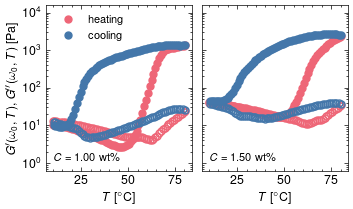

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import chardet
import scienceplots
import os

plt.style.use(['science', 'nature', 'bright'])

# Use the default color cycle from matplotlib
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

# List of CSV files
files = ["../data/processed/dmta/mc_1-0_tempramp_10_1.csv", "../data/processed/dmta/mc_1-5_tempramp_10_1.csv"]
concentrations = ["$C=1.00$ wt\%", "$C=1.50$ wt\%"]  # Text labels for the plots

# Function to detect file encoding
def detect_encoding(file):
    with open(file, 'rb') as f:
        result = chardet.detect(f.read(10000))  # Read first 10kB
    return result['encoding']

# Create subplots (two side-by-side plots)
fig, axes = plt.subplots(ncols=2, figsize=(3.640625, 2.2), sharey=True)  # Share y-axis for better comparison

# Define a list of markers
markers = ['o', 'o', 'p', '*', 'x', '+']

# Loop through each file and plot on separate subplots
for idx, file in enumerate(files):
    encoding = detect_encoding(file)  # Detect encoding
    print(f"Detected encoding for {file}: {encoding}")

    # Read the CSV file with detected encoding
    data_dmta = pd.read_csv(file, skiprows=[0,1,2,4,5], sep="\t", decimal=",", encoding=encoding)
    data_dmta = data_dmta.dropna(how='all')  # Drop empty rows

    # Extract columns
    temperature_dmta = data_dmta['Temperature']
    storage_modulus_dmta = np.log10(data_dmta['Storage Modulus'])
    loss_modulus_dmta = np.log10(data_dmta['Loss Modulus'])

    # Find turning point
    turning_index = np.where(np.diff(temperature_dmta) < 0)[0][0] + 1

    # Split heating and cooling data
    temp_heating = temperature_dmta[:turning_index]
    temp_cooling = temperature_dmta[turning_index:]

    storage_heating = storage_modulus_dmta[:turning_index]
    storage_cooling = storage_modulus_dmta[turning_index:]

    loss_heating = loss_modulus_dmta[:turning_index]
    loss_cooling = loss_modulus_dmta[turning_index:]

    # Assign colors and markers dynamically
    color = colors[idx % len(colors)]  
    marker = markers[idx % len(markers)]  # Cycle through markers

    # Select the corresponding axis for the subplot
    ax = axes[idx]

    # Plot heating
    ax.plot(temp_heating, 10**storage_heating, marker, markersize=5, markevery=1, label='heating', color=colors[1])
    ax.plot(temp_heating, 10**loss_heating, marker, markersize=5, markevery=1, fillstyle="none", color=colors[1])

    # Plot cooling
    ax.plot(temp_cooling, 10**storage_cooling, marker, markersize=5, markevery=1, label='cooling', color=colors[0])
    ax.plot(temp_cooling, 10**loss_cooling, marker, markersize=5, markevery=1, fillstyle="none", color=colors[0])

    # Add text label for concentration
    ax.text(0.05, 0.1, concentrations[idx], transform=ax.transAxes, fontsize=8, verticalalignment='top')

    # Labels and formatting
    ax.set_xlabel('$T$ [$^{\circ}$C]', fontsize=9)
    if idx == 0:  # Only add ylabel to the first subplot
        ax.set_ylabel('$G^{\prime}(\omega_0, T), G^{\prime \prime}(\omega_0, T)~\mathrm{[Pa]}$', fontsize=9)
    ax.set_yscale('log')
    ax.tick_params(labelsize=9)
    ax.set_ylim(10**-0.2, 10**4.2)

# Add legend to the right subplot only
axes[0].legend(fontsize=8, loc="upper left")

plt.tight_layout()

# ---------------- Ensure output folder exists ----------------
out_dir = "../figures/main/dmta_and_mutation"
os.makedirs(out_dir, exist_ok=True)

# ---------------- Save figure ----------------
out_file = os.path.join(out_dir, "dmta_effect_concentration_10rads.pdf")
plt.savefig(out_file, dpi=1200)
plt.show()


Detected encoding for ../data/processed/dmta/mc_1-5_tempramp_10_1-5.csv: UTF-16
Detected encoding for ../data/processed/dmta/mc_1-5_tempramp_10_2.csv: UTF-16


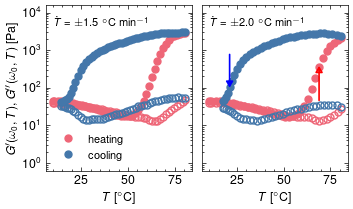

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import chardet
import scienceplots

plt.style.use(['science', 'nature', 'bright'])

# Use the default color cycle from matplotlib
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

# List of CSV files
files = ["../data/processed/dmta/mc_1-5_tempramp_10_1-5.csv", "../data/processed/dmta/mc_1-5_tempramp_10_2.csv"]
concentrations = ["$\dot{T}=\pm1.5~^{\circ}$C min$^{-1}$", "$\dot{T}=\pm2.0~^{\circ}$C min$^{-1}$"]  # Text labels for the plots

# Function to detect file encoding
def detect_encoding(file):
    with open(file, 'rb') as f:
        result = chardet.detect(f.read(10000))  # Read first 10kB
    return result['encoding']

# Create subplots (two side-by-side plots)
fig, axes = plt.subplots(ncols=2, figsize=(3.640625, 2.2), sharey=True)  # Share y-axis for better comparison

# Define a list of markers
markers = ['o', 'o', 'p', '*', 'x', '+']

# Loop through each file and plot on separate subplots
for idx, file in enumerate(files):
    encoding = detect_encoding(file)  # Detect encoding
    print(f"Detected encoding for {file}: {encoding}")

    # Read the CSV file with detected encoding
    data_dmta = pd.read_csv(file, skiprows=[0,1,2,4,5], sep="\t", decimal=",", encoding=encoding)
    data_dmta = data_dmta.dropna(how='all')  # Drop empty rows

    # Extract columns
    temperature_dmta = data_dmta['Temperature']
    storage_modulus_dmta = np.log10(data_dmta['Storage Modulus'])
    loss_modulus_dmta = np.log10(data_dmta['Loss Modulus'])

    # Find turning point
    turning_index = np.where(np.diff(temperature_dmta) < 0)[0][0] + 1

    # Split heating and cooling data
    temp_heating = temperature_dmta[:turning_index]
    temp_cooling = temperature_dmta[turning_index:]

    storage_heating = storage_modulus_dmta[:turning_index]
    storage_cooling = storage_modulus_dmta[turning_index:]

    loss_heating = loss_modulus_dmta[:turning_index]
    loss_cooling = loss_modulus_dmta[turning_index:]

    # Assign colors and markers dynamically
    color = colors[idx % len(colors)]  
    marker = markers[idx % len(markers)]  # Cycle through markers

    # Select the corresponding axis for the subplot
    ax = axes[idx]

    # Plot heating
    ax.plot(temp_heating, 10**storage_heating, marker, markersize=5, markevery=1, label='heating', color=colors[1])
    ax.plot(temp_heating, 10**loss_heating, marker, markersize=5, markevery=1, fillstyle="none", color=colors[1])

    # Plot cooling
    ax.plot(temp_cooling, 10**storage_cooling, marker, markersize=5, markevery=1, label='cooling', color=colors[0])
    ax.plot(temp_cooling, 10**loss_cooling, marker, markersize=5, markevery=1, fillstyle="none", color=colors[0])

    #Plot lines
    #if idx == 0:
    #    ax.axvline(x=62.81, color='k', linestyle='-', linewidth=1.0)
    #    ax.axvline(x=21.94, color='k', linestyle='--', linewidth=1.0)
    #if idx == 1:
    #    ax.axvline(x=68.94, color='k', linestyle='-', linewidth=1.0)
    #    ax.axvline(x=20.95, color='k', linestyle='--', linewidth=1.0)
    # Plot arrows instead of vertical lines
    if idx == 1:
        # Solid line replacement: red upward arrow (heating)
        ax.annotate('', xy=(68.94, 4.5e2), xytext=(68.94, 3.9e1),
                    arrowprops=dict(arrowstyle='-|>,head_width=0.3,head_length=0.5', 
                                    color="red", lw=1.2, fill=False))
        
        # Dashed line replacement: blue downward arrow (cooling)
        ax.annotate('', xy=(20.95, 8.5e1), xytext=(20.95, 9.1e2),
                    arrowprops=dict(arrowstyle='-|>,head_width=0.3,head_length=0.5', 
                                    color='blue', lw=1.2))

    # Add text label for concentration
    ax.text(0.05, 0.93, concentrations[idx], transform=ax.transAxes, fontsize=8, verticalalignment='top',
               bbox=dict(facecolor='none', edgecolor='none', alpha=1.0))

    # Labels and formatting
    ax.set_xlabel('$T$ [$^{\circ}$C]', fontsize=9)
    if idx == 0:  # Only add ylabel to the first subplot
        ax.set_ylabel('$G^{\prime}(\omega_0, T), G^{\prime \prime}(\omega_0, T)~\mathrm{[Pa]}$', fontsize=9)
    ax.set_yscale('log')
    ax.tick_params(labelsize=9)
    ax.set_ylim(10**-0.2, 10**4.2)


# Add legend to the right subplot only
axes[0].legend(fontsize=8, loc="lower left")

plt.tight_layout()

# ---------------- Save figure ----------------
out_file = os.path.join(out_dir, "dmta_effect_heatingrate_10rads.pdf")
plt.savefig(out_file, dpi=1200)
plt.show()

Detected encoding for ../data/processed/dmta/mc_1-5_tempramp_10_1.csv: utf-8
Detected encoding for ../data/processed/dmta/mc_1-5_tempramp_10_1-5.csv: UTF-16
Detected encoding for ../data/processed/dmta/mc_1-5_tempramp_10_2.csv: UTF-16


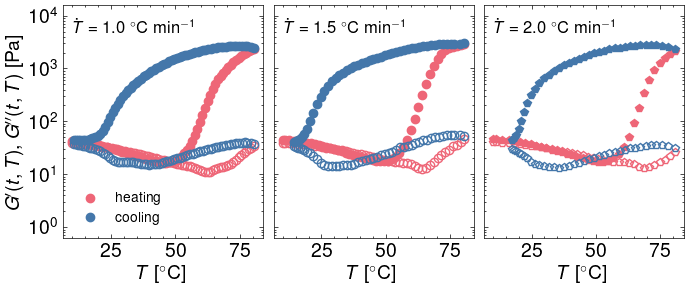

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import chardet
import scienceplots

plt.style.use(['science', 'nature', 'bright'])

# Use the default color cycle from matplotlib
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

# List of CSV files
files = ["../data/processed/dmta/mc_1-5_tempramp_10_1.csv", "../data/processed/dmta/mc_1-5_tempramp_10_1-5.csv", "../data/processed/dmta/mc_1-5_tempramp_10_2.csv"]
T_ramp = ["$\dot{T}=1.0~^{\circ}$C min$^{-1}$", "$\dot{T}=1.5~^{\circ}$C min$^{-1}$", "$\dot{T}=2.0~^{\circ}$C min$^{-1}$"]  # Text labels for the plots

# Function to detect file encoding
def detect_encoding(file):
    with open(file, 'rb') as f:
        result = chardet.detect(f.read(10000))  # Read first 10kB
    return result['encoding']

# Create subplots (two side-by-side plots)
fig, axes = plt.subplots(ncols=3, figsize=(7, 3), sharey=True)  # Share y-axis for better comparison

# Define a list of markers
markers = ['o', 'o', 'p', '*', 'x', '+']

# Loop through each file and plot on separate subplots
for idx, file in enumerate(files):
    encoding = detect_encoding(file)  # Detect encoding
    print(f"Detected encoding for {file}: {encoding}")

    # Read the CSV file with detected encoding
    data_dmta = pd.read_csv(file, skiprows=[0,1,2,4,5], sep="\t", decimal=",", encoding=encoding)
    data_dmta = data_dmta.dropna(how='all')  # Drop empty rows

    # Extract columns
    temperature_dmta = data_dmta['Temperature']
    storage_modulus_dmta = data_dmta['Storage Modulus']
    loss_modulus_dmta = data_dmta['Loss Modulus']

    # Find turning point
    turning_index = np.where(np.diff(temperature_dmta) < 0)[0][0] + 1

    # Split heating and cooling data
    temp_heating = temperature_dmta[:turning_index]
    temp_cooling = temperature_dmta[turning_index:]

    storage_heating = storage_modulus_dmta[:turning_index]
    storage_cooling = storage_modulus_dmta[turning_index:]

    loss_heating = loss_modulus_dmta[:turning_index]
    loss_cooling = loss_modulus_dmta[turning_index:]

    # Assign colors and markers dynamically
    color = colors[idx % len(colors)]  
    marker = markers[idx % len(markers)]  # Cycle through markers

    # Select the corresponding axis for the subplot
    ax = axes[idx]

    # Plot heating
    ax.plot(temp_heating, storage_heating, marker, markersize=6, markevery=1, label='heating', color=colors[1])
    ax.plot(temp_heating, loss_heating, marker, markersize=6, markevery=1, fillstyle="none", color=colors[1])

    # Plot cooling
    ax.plot(temp_cooling, storage_cooling, marker, markersize=6, markevery=1, label='cooling', color=colors[0])
    ax.plot(temp_cooling, loss_cooling, marker, markersize=6, markevery=1, fillstyle="none", color=colors[0])

    # Add text label for concentration
    ax.text(0.05, 0.93, T_ramp[idx], transform=ax.transAxes, fontsize=12, verticalalignment='top')

    # Labels and formatting
    ax.set_xlabel('$T$ [$^{\circ}$C]', fontsize=14)
    if idx == 0:  # Only add ylabel to the first subplot
        ax.set_ylabel('$G^{\prime}(t,T), G^{\prime \prime}(t,T)~\mathrm{[Pa]}$', fontsize=14)
    
    ax.tick_params(labelsize=14)
    ax.set_ylim(10**-0.2, 10**4.2)

    ax.set_yscale('log')


# Add legend to the right subplot only
axes[0].legend(fontsize=10, loc="lower left")

plt.tight_layout()

# ---------------- Save figure ----------------
out_file = os.path.join(out_dir, "dmta_effect_heatingrate_10rads.pdf")
plt.savefig(out_file, dpi=1200)
plt.show()


In [4]:
files = ["../data/processed/dmta/mc_1-5_tempramp_10_0-5.csv", "../data/processed/dmta/mc_1-5_tempramp_10_1.csv", "../data/processed/dmta/mc_1-5_tempramp_10_1-5.csv", "../data/processed/dmta/mc_1-5_tempramp_10_2.csv"]
T_ramp = ["$\dot{T}=\pm0.5~^{\circ}$C min$^{-1}$", "$\dot{T}=\pm1.0~^{\circ}$C min$^{-1}$", "$\dot{T}=\pm1.5~^{\circ}$C min$^{-1}$", "$\dot{T}=\pm2.0~^{\circ}$C min$^{-1}$"]  # Text labels for the plots

# Create an empty list to store results
results = []

for idx, file in enumerate(files):
    encoding = detect_encoding(file)
    data_dmta = pd.read_csv(file, skiprows=[0,1,2,4,5], sep="\t", decimal=",", encoding=encoding)
    data_dmta = data_dmta.dropna(how='all')

    # Extract relevant columns
    temperature_dmta = data_dmta['Temperature'].reset_index(drop=True)
    storage_modulus_dmta = data_dmta['Storage Modulus'].reset_index(drop=True)
    loss_modulus_dmta = data_dmta['Loss Modulus'].reset_index(drop=True)

    # Identify turning point to separate heating and cooling
    turning_index = np.where(np.diff(temperature_dmta) < 0)[0][0] + 1

    # ----------------
    # Heating segment
    # ----------------
    temp_heating = temperature_dmta[:turning_index].reset_index(drop=True)
    storage_heating = storage_modulus_dmta[:turning_index].reset_index(drop=True)
    loss_heating = loss_modulus_dmta[:turning_index].reset_index(drop=True)

    # ---- (1) Minimum of Loss Modulus (heating) ----
    min_index_loss_heat = loss_heating.idxmin()
    min_loss_heat = loss_heating[min_index_loss_heat]
    temp_min_loss_heat = temp_heating[min_index_loss_heat]

    # ---- (2) Maximum derivative of log(Storage Modulus) (heating) ----
    log_storage_heat = np.log10(storage_heating)
    mask_heat = temp_heating.diff().fillna(1) != 0
    temp_clean_heat = temp_heating[mask_heat]
    log_storage_clean_heat = log_storage_heat[mask_heat]
    dlogGdT_heat = np.gradient(log_storage_clean_heat, temp_clean_heat)
    max_deriv_idx_heat = np.nanargmax(dlogGdT_heat)
    max_deriv_heat = dlogGdT_heat[max_deriv_idx_heat]
    temp_max_deriv_heat = temp_clean_heat.iloc[max_deriv_idx_heat]

    # ----------------
    # Cooling segment
    # ----------------
    temp_cooling = temperature_dmta[turning_index:].reset_index(drop=True)
    storage_cooling = storage_modulus_dmta[turning_index:].reset_index(drop=True)
    loss_cooling = loss_modulus_dmta[turning_index:].reset_index(drop=True)

    # ---- (1) Minimum of Loss Modulus (cooling) ----
    min_index_loss_cool = loss_cooling.idxmin()
    min_loss_cool = loss_cooling[min_index_loss_cool]
    temp_min_loss_cool = temp_cooling[min_index_loss_cool]

    # ---- (2) Maximum derivative of log(Storage Modulus) (cooling) ----
    log_storage_cool = np.log10(storage_cooling)
    mask_cool = temp_cooling.diff().fillna(1) != 0
    temp_clean_cool = temp_cooling[mask_cool]
    log_storage_clean_cool = log_storage_cool[mask_cool]
    dlogGdT_cool = np.gradient(log_storage_clean_cool, temp_clean_cool)
    max_deriv_idx_cool = np.nanargmax(dlogGdT_cool)
    max_deriv_cool = dlogGdT_cool[max_deriv_idx_cool]
    temp_max_deriv_cool = temp_clean_cool.iloc[max_deriv_idx_cool]

    # Store all in results
    results.append({
        "T_ramp_label": T_ramp[idx],
        "T_ramp_value": [0.5, 1.0, 1.5, 2.0][idx],
        # Heating
        "Min_Loss_Modulus_Heating": min_loss_heat,
        "Temperature_at_Min_Loss_Heating": temp_min_loss_heat,
        "Max_dlogGdT_Heating": max_deriv_heat,
        "Temperature_at_Max_dlogGdT_Heating": temp_max_deriv_heat,
        # Cooling
        "Min_Loss_Modulus_Cooling": min_loss_cool,
        "Temperature_at_Min_Loss_Cooling": temp_min_loss_cool,
        "Max_dlogGdT_Cooling": max_deriv_cool,
        "Temperature_at_Max_dlogGdT_Cooling": temp_max_deriv_cool
    })

# Convert to DataFrame
df_analysis = pd.DataFrame(results)
print(df_analysis)


                            T_ramp_label  T_ramp_value  \
0  $\dot{T}=\pm0.5~^{\circ}$C min$^{-1}$           0.5   
1  $\dot{T}=\pm1.0~^{\circ}$C min$^{-1}$           1.0   
2  $\dot{T}=\pm1.5~^{\circ}$C min$^{-1}$           1.5   
3  $\dot{T}=\pm2.0~^{\circ}$C min$^{-1}$           2.0   

   Min_Loss_Modulus_Heating  Temperature_at_Min_Loss_Heating  \
0                    10.907                            57.72   
1                    10.969                            62.44   
2                    12.710                            64.29   
3                    12.972                            68.94   

   Max_dlogGdT_Heating  Temperature_at_Max_dlogGdT_Heating  \
0             0.137764                               54.72   
1             0.133964                               60.47   
2             0.152164                               62.81   
3             0.142961                               66.93   

   Min_Loss_Modulus_Cooling  Temperature_at_Min_Loss_Cooling  \
0            

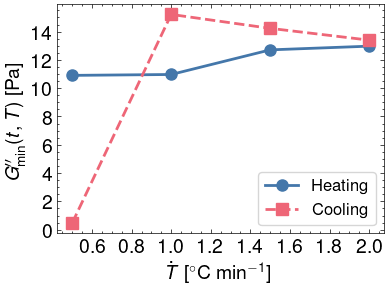

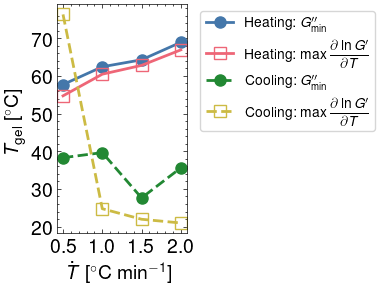

In [5]:
# Convert T_ramp labels to numeric rates for plotting
T_ramp_numeric = [0.5, 1.0, 1.5, 2.0]

plt.figure(figsize=(4,3))

# --- (1) Plot Min Loss Modulus vs Heating/Cooling Rate ---
plt.plot(T_ramp_numeric, df_analysis["Min_Loss_Modulus_Heating"], 'o-', 
         ms=8, lw=2, label='Heating')
plt.plot(T_ramp_numeric, df_analysis["Min_Loss_Modulus_Cooling"], 's--', 
         ms=8, lw=2, label='Cooling')

plt.xlabel('$\dot{T}$ [$^{\circ}$C min$^{-1}$]', fontsize=14)
plt.ylabel('$G_{{\\rm min}}^{\prime\prime}(t,T)$ [Pa]', fontsize=14)
plt.yscale('linear')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=12, frameon=True)
plt.tight_layout()
plt.show()

######################

plt.figure(figsize=(4,3))

# --- (2) Plot Gel Temperatures for Both Heating and Cooling ---
plt.plot(T_ramp_numeric, df_analysis["Temperature_at_Min_Loss_Heating"], 
         'o-', ms=8, lw=2, label="Heating: $G_{{\\rm min}}^{\prime\prime}$")
plt.plot(T_ramp_numeric, df_analysis["Temperature_at_Max_dlogGdT_Heating"], 
         's-', fillstyle="none", ms=8, lw=2, label="Heating: $\\max \\dfrac{\\partial \\ln G^{\prime}}{\\partial T}$")

plt.plot(T_ramp_numeric, df_analysis["Temperature_at_Min_Loss_Cooling"], 
         'o--', ms=8, lw=2, label="Cooling: $G_{{\\rm min}}^{\prime\prime}$")
plt.plot(T_ramp_numeric, df_analysis["Temperature_at_Max_dlogGdT_Cooling"], 
         's--', fillstyle="none", ms=8, lw=2, label="Cooling: $\\max \\dfrac{\\partial \\ln G^{\prime}}{\\partial T}$")

plt.xlabel('$\dot{T}$ [$^{\circ}$C min$^{-1}$]', fontsize=14)
plt.ylabel('$T_{\\rm gel}$~[$^{\circ}$C]', fontsize=14)
plt.yscale('linear')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=10, frameon=True, bbox_to_anchor=(1.05, 1.0))
plt.tight_layout()
plt.show()


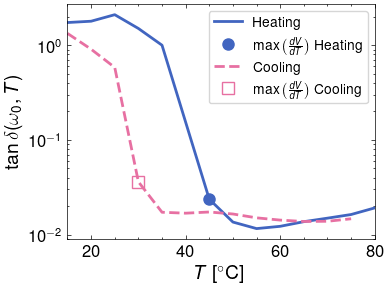

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scienceplots

plt.style.use(['science', 'nature', 'retro'])
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

# --- Load data ---
csv_file = "../results/1.50/tan_alpha_heating_cooling_1_50.csv"  # adjust filename
df_tan_alpha = pd.read_csv(csv_file)

# --- Extract columns ---
Th = df_tan_alpha["Temperature_H"].values
Tc = df_tan_alpha["Temperature_C"].values
Tan_delta_H = df_tan_alpha["Tan_delta_H"].values
Tan_delta_C = df_tan_alpha["Tan_delta_C"].values
Vh = df_tan_alpha["V_H"].values
Vc = df_tan_alpha["V_C"].values

# --- Compute derivatives ---
dVdT_H = np.gradient(np.log(Vh), Th)
dVdT_C = np.gradient(np.log(Vc), Tc)

# --- Find maxima of dV/dT ---
idx_max_dVdT_H = np.nanargmax(dVdT_H)
idx_max_dVdT_C = np.nanargmax(dVdT_C)

T_max_dVdT_H = Th[idx_max_dVdT_H]
T_max_dVdT_C = Tc[idx_max_dVdT_C]

Tan_delta_at_max_H = Tan_delta_H[idx_max_dVdT_H]
Tan_delta_at_max_C = Tan_delta_C[idx_max_dVdT_C]

# --- Plot tan δ vs Temperature ---
plt.figure(figsize=(4,3))

# Heating
plt.plot(Th, Tan_delta_H, '-', color=colors[0], lw=2, label="Heating")
plt.plot(T_max_dVdT_H, Tan_delta_at_max_H, 'o', color=colors[0], markersize=8,
         label="$\\max\\left(\\frac{dV}{dT}\\right)$ Heating")

# Cooling
plt.plot(Tc, Tan_delta_C, '--', color=colors[1], lw=2, label="Cooling")
plt.plot(T_max_dVdT_C, Tan_delta_at_max_C, 's', fillstyle="none", color=colors[1], markersize=8,
         label="$\\max\\left(\\frac{dV}{dT}\\right)$ Cooling")

# --- Formatting ---
plt.xlabel('$T$ [$^{\\circ}$C]', fontsize=14)
plt.ylabel('$\\tan \\delta(\\omega_0, T)$', fontsize=14)
plt.xlim(min(Th.min(), Tc.min()), max(Th.max(), Tc.max()))
plt.yscale('log')
plt.legend(fontsize=10, frameon=True)
plt.tick_params(labelsize=12)
plt.tight_layout()
plt.show()

/m/scicomp/software/anaconda-ci/aalto-ubuntu2004-anaconda/software/anaconda/2023-04/e0d50272/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:419: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/m/scicomp/software/anaconda-ci/aalto-ubuntu2004-anaconda/software/anaconda/2023-04/e0d50272/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:419: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/m/scicomp/software/anaconda-ci/aalto-ubuntu2004-anaconda/software/anaconda/2023-04/e0d50272/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:419: ConvergenceWarning: The optimal value found for dimension 0 of parameter 

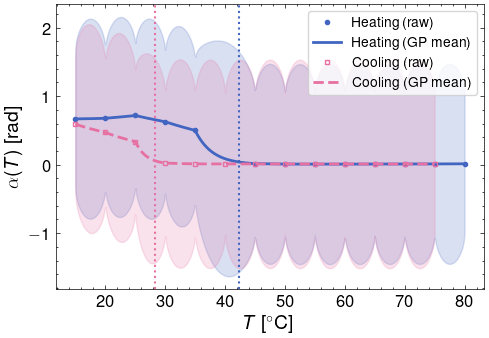

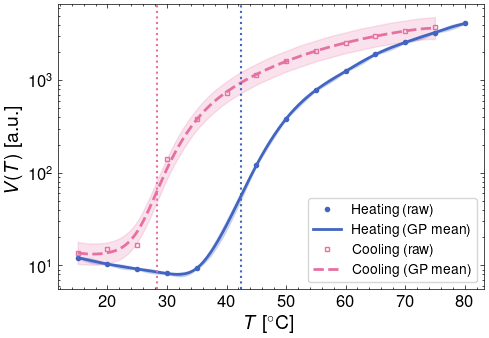

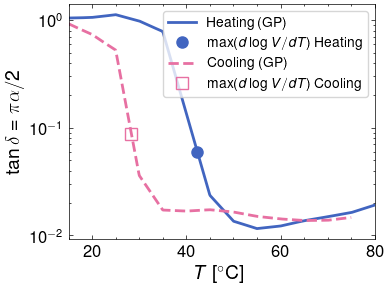

42.35470941883767
28.346693386773545


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, Matern

plt.style.use(['science', 'nature', 'retro'])
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

# --- Load data ---
csv_file = "../results/1.50/tan_alpha_heating_cooling_1_50.csv"
df = pd.read_csv(csv_file)

# --- Extract columns ---
Th = df["Temperature_H"].values
Tc = df["Temperature_C"].values
Vh = df["V_H"].values
Vc = df["V_C"].values
Ah = df["Alpha_H"].values
Ac = df["Alpha_C"].values

# --- Log10 transform for GP stability ---
logVh = np.log10(Vh)
logVc = np.log10(Vc)
logAh = np.log10(Ah)
logAc = np.log10(Ac)

# --- Create dense temperature grids ---
T_dense_H = np.linspace(np.nanmin(Th), np.nanmax(Th), 500)
T_dense_C = np.linspace(np.nanmin(Tc), np.nanmax(Tc), 500)

# ==========================================================
# 🧩 GP for log(V)
# ==========================================================
kernel_V = 1.0 * Matern(nu=1.5, length_scale=1.0, length_scale_bounds=(1e0,1e2)) + WhiteKernel(noise_level=1e-5)
gp_VH = GaussianProcessRegressor(kernel=kernel_V, alpha=0.0, normalize_y=True)
gp_VC = GaussianProcessRegressor(kernel=kernel_V, alpha=0.0, normalize_y=True)

gp_VH.fit(Th.reshape(-1,1), logVh)
gp_VC.fit(Tc.reshape(-1,1), logVc)

logV_dense_H, sigma_VH = gp_VH.predict(T_dense_H.reshape(-1,1), return_std=True)
logV_dense_C, sigma_VC = gp_VC.predict(T_dense_C.reshape(-1,1), return_std=True)

V_dense_H = 10**logV_dense_H
V_dense_C = 10**logV_dense_C

# --- Derivatives of log10(V) w.r.t T ---
dlogVdT_H = np.gradient(logV_dense_H, T_dense_H)
dlogVdT_C = np.gradient(logV_dense_C, T_dense_C)

# --- Max derivative points ---
idx_max_H = np.nanargmax(dlogVdT_H)
idx_max_C = np.nanargmax(dlogVdT_C)
T_max_H = T_dense_H[idx_max_H]
T_max_C = T_dense_C[idx_max_C]

# ==========================================================
# 🧩 GP for log10(α)
# ==========================================================
kernel_A = 1.0 * Matern(nu=0.5, length_scale=1.0, length_scale_bounds=(1e0,1e2)) + WhiteKernel(noise_level=1e-5)
gp_AH = GaussianProcessRegressor(kernel=kernel_A, alpha=0.0, normalize_y=True)
gp_AC = GaussianProcessRegressor(kernel=kernel_A, alpha=0.0, normalize_y=True)

gp_AH.fit(Th.reshape(-1,1), logAh)
gp_AC.fit(Tc.reshape(-1,1), logAc)

logAlpha_dense_H, sigma_AH = gp_AH.predict(T_dense_H.reshape(-1,1), return_std=True)
logAlpha_dense_C, sigma_AC = gp_AC.predict(T_dense_C.reshape(-1,1), return_std=True)

alpha_dense_H = 10**logAlpha_dense_H
alpha_dense_C = 10**logAlpha_dense_C

# --- tan δ = π α / 2 ---
tan_delta_dense_H = np.pi * alpha_dense_H / 2
tan_delta_dense_C = np.pi * alpha_dense_C / 2

tan_delta_at_max_H = np.pi * 10**gp_AH.predict(np.array([[T_max_H]])) / 2
tan_delta_at_max_C = np.pi * 10**gp_AC.predict(np.array([[T_max_C]])) / 2

# ==========================================================
# 0️⃣ α(T) vs T with GP + uncertainty
# ==========================================================
plt.figure(figsize=(5,3.5))
plt.plot(Th, Ah, 'o', color=colors[0], label="Heating (raw)")
plt.plot(T_dense_H, alpha_dense_H, '-', color=colors[0], lw=2, label="Heating (GP mean)")
plt.fill_between(T_dense_H,
                 alpha_dense_H - 10**sigma_AH,
                 alpha_dense_H + 10**sigma_AH,
                 color=colors[0], alpha=0.2)

plt.plot(Tc, Ac, 's', fillstyle="none", color=colors[1], label="Cooling (raw)")
plt.plot(T_dense_C, alpha_dense_C, '--', color=colors[1], lw=2, label="Cooling (GP mean)")
plt.fill_between(T_dense_C,
                 alpha_dense_C - 10**sigma_AC,
                 alpha_dense_C + 10**sigma_AC,
                 color=colors[1], alpha=0.2)

plt.axvline(T_max_H, color=colors[0], ls=':', lw=1.5)
plt.axvline(T_max_C, color=colors[1], ls=':', lw=1.5)

plt.xlabel('$T$ [$^{\\circ}$C]', fontsize=14)
plt.ylabel('$\\alpha(T)$ [rad]', fontsize=14)
plt.legend(fontsize=10, frameon=True)
plt.tick_params(labelsize=12)
plt.tight_layout()
plt.show()

# ==========================================================
# 1️⃣ V(T) vs T with GP + uncertainty
# ==========================================================
plt.figure(figsize=(5,3.5))
plt.plot(Th, Vh, 'o', color=colors[0], label="Heating (raw)")
plt.plot(T_dense_H, V_dense_H, '-', color=colors[0], lw=2, label="Heating (GP mean)")
plt.fill_between(T_dense_H,
                 10**(logV_dense_H - sigma_VH),
                 10**(logV_dense_H + sigma_VH),
                 color=colors[0], alpha=0.2)

plt.plot(Tc, Vc, 's', fillstyle="none", color=colors[1], label="Cooling (raw)")
plt.plot(T_dense_C, V_dense_C, '--', color=colors[1], lw=2, label="Cooling (GP mean)")
plt.fill_between(T_dense_C,
                 10**(logV_dense_C - sigma_VC),
                 10**(logV_dense_C + sigma_VC),
                 color=colors[1], alpha=0.2)

plt.axvline(T_max_H, color=colors[0], ls=':', lw=1.5)
plt.axvline(T_max_C, color=colors[1], ls=':', lw=1.5)

plt.yscale('log')
plt.xlabel('$T$ [$^{\\circ}$C]', fontsize=14)
plt.ylabel('$V(T)$ [a.u.]', fontsize=14)
plt.legend(fontsize=10, frameon=True)
plt.tick_params(labelsize=12)
plt.tight_layout()
plt.show()

# ==========================================================
# 2️⃣ tan δ vs T with GP
# ==========================================================
plt.figure(figsize=(4,3))
plt.plot(T_dense_H, tan_delta_dense_H, '-', color=colors[0], lw=2, label="Heating (GP)")
plt.plot(T_max_H, tan_delta_at_max_H, 'o', color=colors[0], markersize=8,
         label="$\\max(d\\log V/dT)$ Heating")

plt.plot(T_dense_C, tan_delta_dense_C, '--', color=colors[1], lw=2, label="Cooling (GP)")
plt.plot(T_max_C, tan_delta_at_max_C, 's', fillstyle="none", color=colors[1], markersize=8,
         label="$\\max(d\\log V/dT)$ Cooling")

plt.xlabel('$T$ [$^{\\circ}$C]', fontsize=14)
plt.ylabel('$\\tan \\delta = \\pi \\alpha / 2$', fontsize=14)
plt.yscale('log')
plt.xlim(min(Th.min(), Tc.min()), max(Th.max(), Tc.max()))
plt.legend(fontsize=10, frameon=True)
plt.tick_params(labelsize=12)
plt.tight_layout()
plt.show()

print(T_max_H)
print(T_max_C)

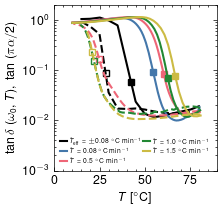

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import chardet
import scienceplots

plt.style.use(['science', 'nature', 'bright'])
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

def detect_encoding(file):
    with open(file, 'rb') as f:
        result = chardet.detect(f.read(10000))
    return result['encoding']

plt.figure(figsize=(2.33, 2.2))

plt.plot(T_dense_H, tan_delta_dense_H, '-', color="k", lw=1.5, label="$\\dot{T}_{\\rm eff} =\pm0.08~^{\circ}{\\rm C~min}^{-1}$")
plt.plot(T_max_H, tan_delta_at_max_H, 's', color="k", markersize=5)

plt.plot(T_dense_C, tan_delta_dense_C, '--', color="k", lw=1.5)
plt.plot(T_max_C, tan_delta_at_max_C, 's', color="k", fillstyle="none", markersize=5)

for idx, file in enumerate(files):
    encoding = detect_encoding(file)
    data_dmta = pd.read_csv(file, skiprows=[0,1,2,4,5], sep="\t", decimal=",", encoding=encoding)
    data_dmta = data_dmta.dropna(how='all')

    temperature_dmta = data_dmta['Temperature'].reset_index(drop=True)
    storage_modulus_dmta = data_dmta['Storage Modulus'].reset_index(drop=True)
    loss_modulus_dmta = data_dmta['Loss Modulus'].reset_index(drop=True)

    # Find turning point (start of cooling)
    turning_index = np.where(np.diff(temperature_dmta) < 0)[0][0] + 1

    # --- Heating segment ---
    temp_heating = temperature_dmta[:turning_index].reset_index(drop=True)
    storage_heating = storage_modulus_dmta[:turning_index].reset_index(drop=True)
    loss_heating = loss_modulus_dmta[:turning_index].reset_index(drop=True)
    loss_factor_heating = loss_heating / storage_heating

    # --- Cooling segment ---
    temp_cooling = temperature_dmta[turning_index:].reset_index(drop=True)
    storage_cooling = storage_modulus_dmta[turning_index:].reset_index(drop=True)
    loss_cooling = loss_modulus_dmta[turning_index:].reset_index(drop=True)
    loss_factor_cooling = loss_cooling / storage_cooling

    # --- Identify points for heating ---
    idx_min_loss_heat = loss_heating.idxmin()
    temp_min_loss_heat = temp_heating[idx_min_loss_heat]
    loss_factor_at_min_heat = loss_factor_heating[idx_min_loss_heat]

    log_storage_heat = np.log10(storage_heating)
    mask_heat = temp_heating.diff().fillna(1) != 0
    temp_clean_heat = temp_heating[mask_heat]
    log_storage_clean_heat = log_storage_heat[mask_heat]
    dlogG_dT_heat = np.gradient(log_storage_clean_heat, temp_clean_heat)
    idx_max_deriv_heat = np.nanargmax(dlogG_dT_heat)
    temp_max_deriv_heat = temp_clean_heat.iloc[idx_max_deriv_heat]
    loss_factor_at_max_deriv_heat = loss_factor_heating[temp_clean_heat.index[idx_max_deriv_heat]]

    # --- Identify points for cooling ---
    idx_min_loss_cool = loss_cooling.idxmin()
    temp_min_loss_cool = temp_cooling[idx_min_loss_cool]
    loss_factor_at_min_cool = loss_factor_cooling[idx_min_loss_cool]

    log_storage_cool = np.log10(storage_cooling)
    mask_cool = temp_cooling.diff().fillna(1) != 0
    temp_clean_cool = temp_cooling[mask_cool]
    log_storage_clean_cool = log_storage_cool[mask_cool]
    dlogG_dT_cool = np.gradient(log_storage_clean_cool, temp_clean_cool)
    idx_max_deriv_cool = np.nanargmax(dlogG_dT_cool)
    temp_max_deriv_cool = temp_clean_cool.iloc[idx_max_deriv_cool]
    loss_factor_at_max_deriv_cool = loss_factor_cooling[temp_clean_cool.index[idx_max_deriv_cool]]

    # --- Plot heating and cooling curves ---
    plt.plot(temp_heating, loss_factor_heating, '-', lw=1.5, color=colors[idx], 
             label=f"{T_ramp[idx]}")
    if idx > 0:
        plt.plot(temp_cooling, loss_factor_cooling, '--', lw=1.5, color=colors[idx], 
            )

    # --- Mark characteristic points ---
    #plt.plot(temp_min_loss_heat, loss_factor_at_min_heat, 'o', color=colors[idx], markersize=7)
    plt.plot(temp_max_deriv_heat, loss_factor_at_max_deriv_heat, 's', 
             color=colors[idx], markersize=5)
    #plt.plot(temp_min_loss_cool, loss_factor_at_min_cool, 'o', color=colors[idx], markersize=7)
    if idx > 0:
        plt.plot(temp_max_deriv_cool, loss_factor_at_max_deriv_cool, 's', fillstyle="none", 
             color=colors[idx], markersize=5)

# --- Plot formatting ---
plt.xlabel('$T$ [$^{\circ}$C]', fontsize=9)
plt.ylabel('$\\tan \\delta~(\\omega_0, T),~ \\tan~(\\pi \\alpha / 2)$', fontsize=9)
plt.xlim(0, 90)
plt.ylim(0.001, 2)
plt.yscale('log')
plt.tick_params(labelsize=9)
plt.legend(fontsize=4.9, ncol=2, frameon=False, loc="best",
           handlelength=1.0, handletextpad=0.4, columnspacing=0.2     # tighten column separation
)
plt.tight_layout()

# ---------------- Save figure ----------------
out_file = os.path.join(out_dir, "loss_factor_heating_cooling.pdf")
plt.savefig(out_file, dpi=1200)
plt.show()


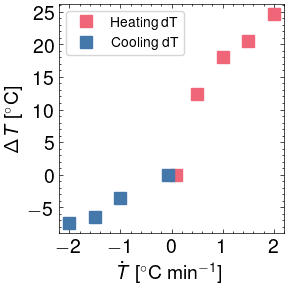

In [9]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use(['science', 'nature', 'bright'])
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

# --- Assume 0 heating rate for V and alpha data ---
T_max_V_alpha_H = T_max_H  # from your GP-interpolated V/alpha heating
T_max_V_alpha_C = T_max_C  # from your GP-interpolated V/alpha cooling

# --- Calculate differences (ΔT) for heating ramps ---
delta_T_heating = df_analysis["Temperature_at_Max_dlogGdT_Heating"].values - T_max_V_alpha_H
delta_T_cooling = df_analysis["Temperature_at_Max_dlogGdT_Cooling"].values - T_max_V_alpha_C

# --- Ramp rates ---
T_ramp_numeric = [0.5, 1.0, 1.5, 2.0]  # °C/min
T_ramp_numeric_cooling = [-0.5, -1.0, -1.5, -2.0]  # °C/min

# --- Plot differences ---
plt.figure(figsize=(3,3))
plt.plot(T_ramp_numeric, delta_T_heating, 's', color=colors[1], ms=8, lw=2, label="Heating dT")
plt.plot([0.08], [0], 's', color=colors[1], ms=8, lw=2)

plt.plot(T_ramp_numeric_cooling[1:], delta_T_cooling[1:], 's', color=colors[0], ms=8, lw=2, label="Cooling dT")
plt.plot([-0.08], [0], 's', color=colors[0], ms=8, lw=2)


plt.xlabel('$\dot{T}$ [$^{\circ}$C min$^{-1}$]', fontsize=14)
plt.ylabel('$\\Delta T$~[$^{\circ}$C]', fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=10, frameon=True)
plt.tight_layout()
plt.show()

In [10]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use(['science', 'nature', 'bright'])
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

# --- Ramp rates ---
T_ramp_numeric = [0.5, 1.0, 1.5, 2.0]  # °C/min
T_ramp_numeric_cooling = [-0.5, -1.0, -1.5, -2.0]  # °C/min


# --- Gel temperatures from ramps ---
Tgel_heating = df_analysis["Temperature_at_Max_dlogGdT_Heating"].values
Tgel_cooling = df_analysis["Temperature_at_Max_dlogGdT_Cooling"].values

# --- Gel temperature at quasi-static heating (rate = 0) ---
Tgel_zero_H = T_max_H  # from GP V/alpha
Tgel_zero_C = T_max_C

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

plt.style.use(['science', 'nature', 'bright'])
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

# --- Ramp rates including zero-rate ---
T_ramp_heating = [0.08] + T_ramp_numeric  # 0 and heating ramps
T_ramp_cooling = [-0.08] + [-r for r in T_ramp_numeric[1:]]  # 0 and cooling ramps, negative

# --- Corresponding Tgel values ---
Tgel_heating_all = [Tgel_zero_H] + list(Tgel_heating)
Tgel_cooling_all = [Tgel_zero_C] + list(Tgel_cooling[1:])  # skip faulty first point

# --- Build single DataFrame ---
df_Tgel = pd.DataFrame({
    'Ramp_rate': T_ramp_heating + T_ramp_cooling,
    'Heating_Cooling': ['H']*len(T_ramp_heating) + ['C']*len(T_ramp_cooling),
    'Tgel': Tgel_heating_all + Tgel_cooling_all
})

print(df_Tgel)

# --- Compute derivative using finite differences ---
def compute_derivative(ramp_rates, tgel):
    ramp_rates = np.array(ramp_rates)
    tgel = np.array(tgel)
    dTgel_dTdot = np.gradient(tgel, ramp_rates)  # simple finite difference
    return dTgel_dTdot

# Heating derivative
dTgel_dTdot_H = compute_derivative(T_ramp_heating, Tgel_heating_all)

# Cooling derivative
dTgel_dTdot_C = compute_derivative(T_ramp_cooling, Tgel_cooling_all)

# Add derivatives to DataFrame
df_Tgel['dTgel_dTdot'] = list(dTgel_dTdot_H) + list(dTgel_dTdot_C)

print(df_Tgel)
# [1, 0.77402611476, 0.70042515296, 0.6743306639, 0.63282099208 ]

   Ramp_rate Heating_Cooling       Tgel
0       0.08               H  42.354709
1       0.50               H  54.720000
2       1.00               H  60.470000
3       1.50               H  62.810000
4       2.00               H  66.930000
5      -0.08               C  28.346693
6      -1.00               C  24.740000
7      -1.50               C  21.940000
8      -2.00               C  20.950000
   Ramp_rate Heating_Cooling       Tgel  dTgel_dTdot
0       0.08               H  42.354709    29.441168
1       0.50               H  54.720000    21.250635
2       1.00               H  60.470000     8.090000
3       1.50               H  62.810000     6.460000
4       2.00               H  66.930000     8.240000
5      -0.08               C  28.346693     3.920319
6      -1.00               C  24.740000     5.008563
7      -1.50               C  21.940000     3.790000
8      -2.00               C  20.950000     1.980000


In [12]:
# --- Linear function ---
def linear(x, k, m):
    return k + m*x

# Heating fit
mask_H = df_Tgel['Heating_Cooling'] == 'H'
popt_H, _ = curve_fit(linear, df_Tgel['Ramp_rate'][mask_H], df_Tgel['Tgel'][mask_H])

# Cooling fit
mask_C = df_Tgel['Heating_Cooling'] == 'C'
popt_C, _ = curve_fit(linear, df_Tgel['Ramp_rate'][mask_C], df_Tgel['Tgel'][mask_C])

print("Heating fit parameters: k = {:.3f}, m = {:.3f}".format(*popt_H))
print("Cooling fit parameters: k = {:.3f}, m = {:.3f}".format(*popt_C))


Heating fit parameters: k = 45.581, m = 11.689
Cooling fit parameters: k = 28.589, m = 4.013


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


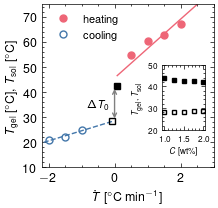

In [25]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.ticker import MultipleLocator


# --- Main figure (example) ---
plt.figure(figsize=(2.33, 2.2))
plt.plot(T_ramp_numeric, Tgel_heating, 'o', color=colors[1], ms=5, lw=2, label="heating")
plt.plot(T_ramp_numeric_cooling[1:], Tgel_cooling[1:], 'o', fillstyle="none", color=colors[0], ms=5, lw=2, label="cooling")
# Linear fits
x_fit_heat = np.linspace(0.08, 2.5, 100)
x_fit_cool = np.linspace(-0.08, -2.5, 100)
plt.plot(x_fit_heat, linear(x_fit_heat, *popt_H),  '-', c=colors[1])
plt.plot(x_fit_cool, linear(x_fit_cool, *popt_C), '--', c=colors[0])
# Zero-rate references
plt.plot(0.08, Tgel_zero_H, 's', color="k", ms=5)
plt.plot(-0.08, Tgel_zero_C, 's', fillstyle="none", color="k", ms=5)

# Add a double-headed arrow between heating and cooling
plt.annotate(
    '', xy=(0.0, Tgel_zero_H), xytext=(0.0, Tgel_zero_C),
    arrowprops=dict(arrowstyle='<->', color='gray', lw=1)
)

# Optional: add text label near the arrow
plt.text(-0.5, Tgel_zero_C + 5, '$\Delta T_{0}$', ha='center', va='bottom', fontsize=8)

plt.ylim(10, 75)
plt.xlim(-2.2, 3)
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
plt.xlabel(r'$\dot{T}$ [$^{\circ}$C min$^{-1}$]', fontsize=9)
plt.ylabel('$T_{\\rm gel}$~[$^{\circ}$C], $T_{\\rm sol}$~[$^{\circ}$C]', fontsize=9)
plt.legend(fontsize=8, frameon=False)
plt.tight_layout()

# --- Data for inset ---
x = [1.00, 1.25, 1.50, 1.75, 2.00]
Tgel_points = [43.78, 43.00, 42.35, 42.61, 42.09]
Conc_points = [28.10, 28.22, 28.34, 28.70, 28.70]

# --- Add inset ---
ax_inset = inset_axes(
    plt.gca(),
    width="25%", height="40%",
    loc="lower right",
    bbox_to_anchor=(-0.02, 0.20, 1, 1),  # (x_shift, y_shift, width, height)
    bbox_transform=plt.gca().transAxes,  # interpret shift in axes fraction (0–1)
)

# Plot both datasets
ax_inset.plot(x, Tgel_points, 's', color="k")
ax_inset.plot(x, Conc_points, 's', fillstyle="none", color="k")

# Style inset
ax_inset.set_xlabel('$C$~[wt\%]', fontsize=6)
ax_inset.set_ylabel('$T_{\\rm gel}$, $T_{\\rm sol}$', fontsize=6)
ax_inset.set_ylim(20, 50)

ax_inset.xaxis.set_major_locator(MultipleLocator(0.5))

ax_inset.tick_params(labelsize=6)
ax_inset.legend(fontsize=6, frameon=False)

# ---------------- Save figure ----------------
out_file = os.path.join(out_dir, "Tgel_vs_Tramp_with_inset_dual.pdf")
plt.savefig(out_file, bbox_inches="tight", dpi=1200)
plt.show()



In [14]:
# 1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mastercurves import MasterCurve
from mastercurves.transforms import Multiply
from sklearn.gaussian_process.kernels import Matern, ConstantKernel, WhiteKernel
import chardet

# ------------------ Helper function ------------------
def detect_encoding(file):
    with open(file, 'rb') as f:
        result = chardet.detect(f.read(10000))
    return result['encoding']

# ------------------ File lists ------------------
quasi_static_file_H = "../results/1.50/tan_alpha_heating_cooling_1_50.csv"
quasi_static_file_C = "../results/1.50/tan_alpha_heating_cooling_1_50.csv"

ramp_files = ["../data/processed/dmta/mc_1-5_tempramp_10_0-5.csv", "../data/processed/dmta/mc_1-5_tempramp_10_1.csv",
              "../data/processed/dmta/mc_1-5_tempramp_10_1-5.csv", "../data/processed/dmta/mc_1-5_tempramp_10_2.csv"]

# ------------------ Load quasi-static data ------------------
df_H_qs = pd.read_csv(quasi_static_file_H)
T_qs_H = df_H_qs["Temperature_H"].values
tan_delta_qs_H = np.pi * df_H_qs["Alpha_H"].values / 2

df_C_qs = pd.read_csv(quasi_static_file_C)
T_qs_C = df_C_qs["Temperature_C"].values
tan_delta_qs_C = np.pi * df_C_qs["Alpha_C"].values / 2

# ------------------ Load ramp data ------------------
T_ramp_H_list = []
tan_delta_H_list = []

T_ramp_C_list = []
tan_delta_C_list = []

for idx, file in enumerate(ramp_files):
    encoding = detect_encoding(file)
    df = pd.read_csv(file, skiprows=[0,1,2,4,5], sep="\t", decimal=",", encoding=encoding)
    df = df.dropna(how='all')

    temperature = df['Temperature'].reset_index(drop=True)
    storage_modulus = df['Storage Modulus'].reset_index(drop=True)
    loss_modulus = df['Loss Modulus'].reset_index(drop=True)
    tan_delta = loss_modulus / storage_modulus

    # Turning point for cooling
    turning_index = np.where(np.diff(temperature) < 0)[0][0] + 1

    # Heating
    T_heating = temperature[:turning_index].values
    tan_delta_heating = tan_delta[:turning_index].values
    T_ramp_H_list.append(T_heating)
    tan_delta_H_list.append(tan_delta_heating)

    # Cooling: skip first ramp (0.5°C/min) if faulty
    if idx == 0:
        continue
    T_cooling = temperature[turning_index:].values
    tan_delta_cooling = tan_delta[turning_index:].values
    T_ramp_C_list.append(T_cooling)
    tan_delta_C_list.append(tan_delta_cooling)

# ------------------ Shift factors ------------------
shift_factors_ = [1, 0.77402611476, 0.70042515296, 0.6743306639, 0.63282099208]
shift_factors_C = [1, 1.14578387227, 1.2920097083, 1.35306410501]

# ------------------ Prepare data ------------------
# Assuming you already defined:
# T_dense_H, tan_delta_dense_H
# T_ramp_H_list, tan_delta_H_list

# Combine all heating datasets into one list (reference + 4 ramps)
T_all_H = [T_dense_H] + T_ramp_H_list
tan_delta_all_H = [tan_delta_dense_H] + tan_delta_H_list

# Apply horizontal scaling (temperature shift)
T_all_H_shifted = [T * f for T, f in zip(T_all_H, shift_factors_)]

# ------------------ Plot all shifted datasets ------------------
# Define labels for each heating ramp (same order as your datasets)
T_ramp = [
    r"$\dot{T}=0.08~^{\circ}\mathrm{C~min^{-1}}$",
    r"$\dot{T}=0.5~^{\circ}\mathrm{C~min^{-1}}$",
    r"$\dot{T}=1.0~^{\circ}\mathrm{C~min^{-1}}$",
    r"$\dot{T}=1.5~^{\circ}\mathrm{C~min^{-1}}$",
    r"$\dot{T}=2.0~^{\circ}\mathrm{C~min^{-1}}$",
]

# Combine all heating datasets into one list (reference + 4 ramps)
T_all_C = [T_dense_C] + T_ramp_C_list
tan_delta_all_C = [tan_delta_dense_C] + tan_delta_C_list

# Apply horizontal scaling (temperature shift)
T_all_C_shifted = [T * f for T, f in zip(T_all_C, shift_factors_C)]

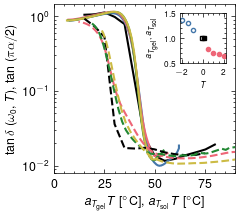

In [26]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.ticker import MaxNLocator

# --- Style setup ---
plt.style.use(['science', 'nature', 'bright'])
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

# Define labels (ensure order matches dataset lists)
T_ramp_H = [
    r"$\dot{T}\approx0.0~^{\circ}\mathrm{C~min^{-1}}$",
    r"$\dot{T}=0.5~^{\circ}\mathrm{C~min^{-1}}$",
    r"$\dot{T}=1.0~^{\circ}\mathrm{C~min^{-1}}$",
    r"$\dot{T}=1.5~^{\circ}\mathrm{C~min^{-1}}$",
    r"$\dot{T}=2.0~^{\circ}\mathrm{C~min^{-1}}$",
]

T_ramp_C = [
    r"$\dot{T}\approx0.0~^{\circ}\mathrm{C~min^{-1}}$",
    r"$\dot{T}=1.0~^{\circ}\mathrm{C~min^{-1}}$",
    r"$\dot{T}=1.5~^{\circ}\mathrm{C~min^{-1}}$",
    r"$\dot{T}=2.0~^{\circ}\mathrm{C~min^{-1}}$",
]

# --- Map colors consistently across heating & cooling ---
color_dict = {
    T_ramp_H[0]: "k",
    T_ramp_H[1]: colors[0],
    T_ramp_H[2]: colors[1],
    T_ramp_H[3]: colors[2],
    T_ramp_H[4]: colors[3],
}

# --- Main plot ---
plt.figure(figsize=(2.33, 2.2))
ax = plt.gca()

# Heating curves — solid lines
for label, (T, tan_delta, f) in zip(T_ramp_H, zip(T_all_H_shifted, tan_delta_all_H, shift_factors_)):
    ax.plot(T, tan_delta, "-", lw=1.5, color=color_dict[label], label=label)

# Cooling curves — dashed lines
for label, (T, tan_delta, f) in zip(T_ramp_C, zip(T_all_C_shifted, tan_delta_all_C, shift_factors_C)):
    ax.plot(T, tan_delta, '--', lw=1.5, color=color_dict[label])

# --- Axes, labels, legend ---
ax.set_xlabel(r'$a_{T_{\rm gel}}T$ [$^{\circ}$C], $a_{T_{\rm sol}}T$ [$^{\circ}$C]', fontsize=9)
ax.set_ylabel(r'$\tan \delta~(\omega_0, T)$, $\tan~(\pi \alpha /2)$', fontsize=9)
ax.set_xlim(0, 90)
#ax.set_ylim(0.001, 2)
ax.set_yscale('log')
ax.tick_params(labelsize=9)
#ax.legend(fontsize=5, ncol=2, frameon=False, loc="best",
#           handlelength=1.0, handletextpad=0.4, columnspacing=0.6)

# --- Inset: shift factors vs heating rate ---
inset_ax = inset_axes(
    ax,
    width="28%",
    height="33%",
    loc="upper right",
    bbox_to_anchor=(0.05, 0.05, 0.9, 0.9),  # fine-tune position inside axes
    bbox_transform=ax.transAxes,
    borderpad=0,
)
# X data (heating rates)
rates_H = [0.08, 0.5, 1.0, 1.5, 2.0]
rates_C = [-0.08, -1.0, -1.5, -2.0]

# Heating: first point as square, rest as circles
inset_ax.plot(rates_H[0], shift_factors_[0], 's', color="k")  # first point (square)
if len(rates_H) > 1:
    inset_ax.plot(rates_H[1:], shift_factors_[1:], 'o', color=colors[1], label='heating')  # rest (circles)

# Cooling: first point as square, rest as open circles
inset_ax.plot(rates_C[0], shift_factors_C[0], 's', fillstyle="none", color="k")  # first point (square)
if len(rates_C) > 1:
    inset_ax.plot(rates_C[1:], shift_factors_C[1:], 'o', fillstyle="none", color=colors[0], label='cooling')  # rest


# Format inset
inset_ax.set_xlabel(r'$§\dot{T}$', fontsize=6)
inset_ax.set_ylabel(r'$a_{T_{\rm gel}}, a_{T_{\rm sol}}$', fontsize=6)
inset_ax.tick_params(axis='both', labelsize=6)
#inset_ax.legend(fontsize=4, frameon=False)

# Force all major ticks to appear
#inset_ax.xaxis.set_major_locator(MaxNLocator(integer=False, nbins=3, prune=None))
#inset_ax.yaxis.set_major_locator(MaxNLocator(integer=False, nbins=3, prune=None))

#inset_ax.legend(fontsize=5, frameon=False)
inset_ax.grid(False)
#inset_ax.set_xlim(0, 2.1)
inset_ax.set_ylim(0.5, 1.5)

# Optional: give it a subtle white background to stand out
inset_ax.set_facecolor("white")
inset_ax.patch.set_alpha(0.9)

#plt.tight_layout()

# ---------------- Save figure ----------------
out_file = os.path.join(out_dir, "loss_factor_heating_cooling_shifted_weighted_style_with_inset.pdf")
plt.savefig(out_file, bbox_inches="tight", dpi=1200)
plt.show()